# Strategic Performance Analytics: CS:GO Tactical Intelligence

### **1. Business Context: What is CS:GO?**
**Counter-Strike: Global Offensive (CS:GO)** is a tactical, round-based objective shooter. At its core, it is a **high-stakes resource management simulation** where two teams of five (Terrorists vs. Counter-Terrorists) compete to plant or defuse an explosive objective.

Success in CS:GO is driven by two primary analytical levers:
* **The Economy:** Players earn currency based on round outcomes to purchase equipment. 
* **The Geometry:** Teams must optimize their spatial positioning ($x, y, z$ coordinates) to gain a mathematical advantage in engagements.

### **2. The Analytical Framework**
In competitive play, rounds are often won or lost before a single shot is fired. While "aim" is a variable, **spatial positioning** is a constant that can be optimized through data.

**The Situation:** Professional matches generate massive amounts of event-level telemetry.
**The Complication:** Raw telemetry is unstructured. Standard metrics like "Kills/Deaths" fail to capture *where* and *why* a team dominated a map.
**The Objective:** This analysis uses spatial data to identify "Defensive Anchors" and "Power Positions" that yield the highest probability of round success.

---

### **3. Key Research Questions**
To extract actionable insights from the movement data, this notebook addresses:

* **Zone Occupancy & Control:** Identifying "high-traffic" versus "high-lethality" zones.
* **Post-Plant Geometry:** Analyzing how the optimal defensive perimeter shifts once the bomb is active.
* **Engagement ROI:** Correlating weapon choice (e.g., AWP vs. AK-47) with spatial "Effective Combat Radii."
* **Survival Heatmaps:** Identifying "Power Positions" through spatial kill-to-death ratios.

---

### **4. Methodology**
We utilize a coordinate-transformation script (leveraging logic from [billfreeman44](https://www.kaggle.com/billfreeman44)) to map raw game engine units to a normalized 2D grid. This allows for the generation of density heatmaps and spatial clustering to identify common defensive setups on **de_mirage**.

> **Note on Data Source:** This analysis uses the [CS:GO Competitive Matchmaking Data](https://www.kaggle.com/datasets/skihikingkevin/csgo-matchmaking-damage#mm_master_demos.csv) dataset, focusing on "Normal" and "Pistol" rounds to filter for standard tactical behavior.


# CS:GO positionning analysis

In tactical esports, positioning is the primary driver of round outcomes. This section transitions from raw event logs to Spatial Telemetry, mapping the $x, y$ coordinates of player interactions to identify "Defensive Anchors"—specific map locations that yield the highest mathematical probability of stopping an offensive push.

# The Analytical Framework

To extract actionable insights from the movement data, this analysis addresses the following core questions:

* **Zone Occupancy & Control:** Which areas of the map are "high-traffic" versus "high-lethality"? We distinguish between where players spend time and where they actually win engagements.
* **The Post-Plant Geometry:** Once the objective (bomb) is active, how does the optimal defensive perimeter shift? 
* **Engagement Distance vs. Weapon Choice:** We correlate spatial coordinates with weapon types (e.g., Rifles vs. SMGs) to visualize the "Effective Combat Radius" of each equipment class.
* **Survival Heatmaps:** By overlaying "Death Events" with "Position Events," we identify "Power Positions."

### Methodology
We utilize a coordinate-transformation script to map raw game engine units to a normalized 2D grid, allowing for the generation of density heatmaps.


For my first Kernel I decided to work on a game that I like which is Counter Strike Global Offensive.<br>
As Counter Strike Global Offensive relies on defending bomb sites, it is a useful information to know where the bullets might be coming from when attacking a bomb site or where to position yourself to defend.<br>
The goal of this Kernel is to determine what are the most common and efficient positions played on the Counter Terrorist (CT) side before the bomb is planted, and the positions played by the Terrorists (T) side after the bomb is planted.

I'll be using data from [skihikingkevin's CS:GO Dataset](https://www.kaggle.com/skihikingkevin/csgo-matchmaking-damage#mm_master_demos.csv). And I'll limit my analysis to de_mirage which is my favourite map.
<br>
I borrowed some code from [billfreeman44's T side smokes on mirage kernel](https://www.kaggle.com/billfreeman44/finding-classic-smokes-by-t-side-on-mirage) don't hesitate to give it a look it's pretty interesting espescially as smokes are a big part of mirage's gameplay !

1. The data<br>
2. CT Side defense analysis<br>
  2.1. Positions regardless of weapons<br>
  2.2. Specific case : AWP<br>
3. T Side defense analysis<br>
  3.1. Bombsite A<br>
  3.2. Bombsite B<br>

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

data = pd.read_csv('../input/mm_master_demos.csv')
analyzed_map = 'de_mirage' # It's the best map after all !!!

# Filter by map & type of rounds, we don't want eco rounds as those tend to be more agressive
data = data[(data.map == analyzed_map) & ((data.round_type == 'PISTOL_ROUND') | (data.round_type == 'NORMAL'))]

In [11]:
# Used to convert Dataset positions to positions on the radar
# Keep in mind that the startX, endX resX, startY, endY, resY are specific to mirage, coordinates for each map are available in the dataset

def pointx_to_resolutionx(xinput,startX=-3217,endX=1912,resX=1024):
    sizeX=endX-startX
    if startX < 0:
        xinput += startX *(-1.0)
    else:
        xinput += startX
    xoutput = float((xinput / abs(sizeX)) * resX);
    return xoutput

def pointy_to_resolutiony(yinput,startY=-3401,endY=1682,resY=1024):
    sizeY=endY-startY
    if startY < 0:
        yinput += startY *(-1.0)
    else:
        yinput += startY
    youtput = float((yinput / abs(sizeY)) * resY);
    return resY-youtput

# Convert the data to radar positions
data['attacker_mapX'] = data['att_pos_x'].apply(pointx_to_resolutionx)
data['attacker_mapY'] = data['att_pos_y'].apply(pointy_to_resolutiony)

## 1. The Data

This dataset consists of more than **30,000 rounds** where each line of data represents a individual damage entry. To understand tactical performance, we will focus specifically on **attacker positioning** and the **bomb state** (planted vs. not planted).

Below is a preview of the raw telemetry. Note that the coordinates ($x, y$) are in raw game units; we will apply a linear transformation in the next step to map these accurately onto our 2D radar assets.

In [3]:
data.head()

,Unnamed: 0,file,map,date,round,tick,seconds,att_team,vic_team,att_side,vic_side,hp_dmg,arm_dmg,is_bomb_planted,bomb_site,hitbox,wp,wp_type,award,winner_team,winner_side,att_id,att_rank,vic_id,vic_rank,att_pos_x,att_pos_y,vic_pos_x,vic_pos_y,round_type,ct_eq_val,t_eq_val,avg_match_rank,attacker_mapX,attacker_mapY
4269,0,003218553373129179487_1555113029.dem,de_mirage,09/28/2017 8:44:36 PM,1,7392,115.9530,Team 1,Team 2,CounterTerrorist,Terrorist,100,0,False,NaN,Head,USP,Pistol,300,Team 2,Terrorist,76561198115686363,16,76561198370068230,16,-359.5016,389.7257,-468.7209,529.1569,PISTOL_ROUND,4250,4200,15.0,570.496853,260.336196
4270,1,003218553373129179487_1555113029.dem,de_mirage,09/28/2017 8:44:36 PM,1,7394,115.9842,Team 2,Team 1,Terrorist,CounterTerrorist,15,8,False,NaN,Stomach,Glock,Pistol,300,Team 2,Terrorist,76561198355692407,17,76561198115686363,16,-650.1707,520.0313,-352.4009,392.1384,PISTOL_ROUND,4250,4200,15.0,512.465043,234.085373
4271,2,003218553373129179487_1555113029.dem,de_mirage,09/28/2017 8:44:36 PM,1,7404,116.1405,Team 2,Team 1,Terrorist,CounterTerrorist,85,0,False,NaN,Head,Glock,Pistol,300,Team 2,Terrorist,76561198355692407,17,76561198115686363,16,-650.1707,520.0313,-335.1208,401.2988,PISTOL_ROUND,4250,4200,15.0,512.465043,234.085373
4272,3,003218553373129179487_1555113029.dem,de_mirage,09/28/2017 8:44:36 PM,1,8154,127.8608,Team 1,Team 2,CounterTerrorist,Terrorist,100,0,False,NaN,Head,USP,Pistol,300,Team 2,Terrorist,76561198152153688,16,76561198301910020,13,-2064.0290,793.1069,-1575.5010,685.9157,PISTOL_ROUND,4250,4200,15.0,230.189570,179.072700
4273,4,003218553373129179487_1555113029.dem,de_mirage,09/28/2017 8:44:36 PM,1,8162,127.9858,Team 2,Team 1,Terrorist,CounterTerrorist,100,0,False,NaN,Head,USP,Pistol,300,Team 2,Terrorist,76561198355692407,17,76561198152153688,16,-1090.8520,677.1235,-2063.8480,793.9529,PISTOL_ROUND,4250,4200,15.0,424.483438,202.438233


## 2. CT-Side Defensive Analysis

To understand optimal Counter-Terrorist (CT) positioning, we first filter for actions that occurred **before the bomb was planted**. This allows us to analyze the "Default" defensive setup.

**The Strategy:** We are specifically filtering for rounds where the **CT side won**. This serves as a proxy for measuring **Defensive Efficiency**—by identifying the positions most frequently occupied during successful round outcomes, we can map out the "Winning Geometry" of the map.

### **2.1. Aggregated Positional Heatmap (All Weapons)**

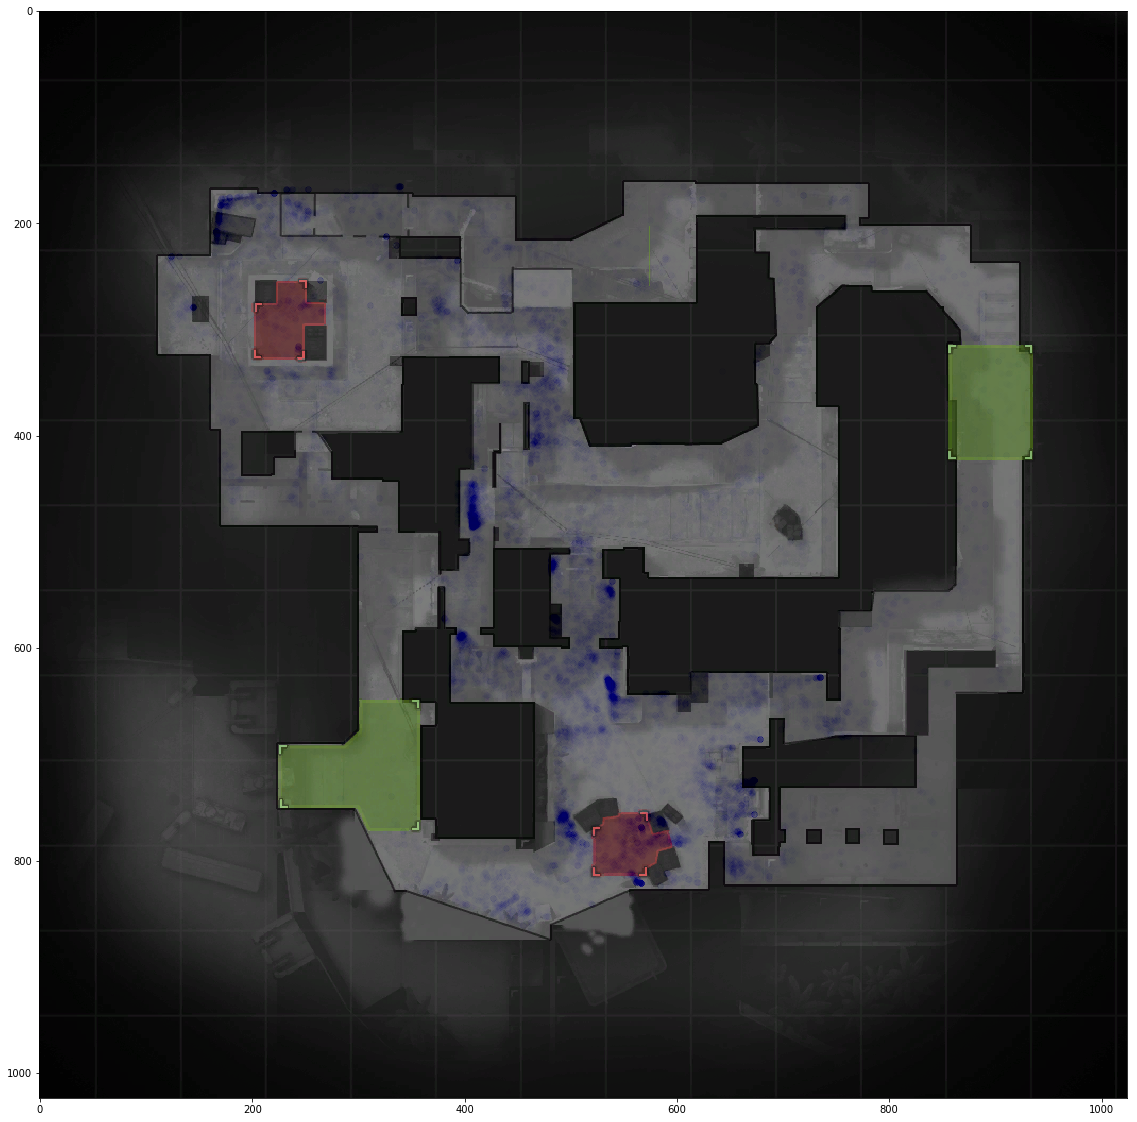

In [18]:
ct_data = data[(data.is_bomb_planted == False) & (data.att_side == 'CounterTerrorist') & (data.winner_side == 'CounterTerrorist')]

im = plt.imread('../input/de_mirage.png')
plt.figure(figsize=(20,20))
t = plt.imshow(im)
t = plt.scatter(ct_data['attacker_mapX'], ct_data['attacker_mapY'],alpha=0.005,c='blue')

### **2.1. Spatial Analysis: Winning Defensive Anchors**

The scatter plot reveals the "Winning Geometry" of Mirage. By filtering for successful CT rounds, we can identify which defensive positions yield the highest mathematical efficiency.

#### **Bombsite A (Bottom Red Site)**
* **High-Ground Control:** Success is concentrated at **Stairs, Jungle, and Window**. This confirms that a tiered defense (verticality) is superior for site retakes and entry denial.
* **Proactive Mid-Control:** High density in **Connector** suggests that winning teams prioritize disrupting the Terrorist "Mid" transition before they can execute on the site.

#### **Bombsite B (Top Red Site)**
* **The Bottleneck Strategy:** The primary winning cluster is located at **Van and the Apartments exit**. Efficiency on B is achieved by "Close-Contact" defense—denying the entry at the narrowest point rather than playing from the back of the site.
* **Rotation Support:** Significant density along the **Catwalk/Short** corridor highlights the importance of mobile defenders who can support both sites.

> **Strategic Conclusion:** Winning CT defenses are **proactive**. Efficiency is not found in passive hiding, but in occupying "Power Positions" that contest entry paths early in the round.

---

### **2.2. The AWP (Sniper Rifle)**

**Overview:**
The AWP is the most expensive and highest-impact defensive tool in the Counter-Terrorist arsenal ($4,750). Due to its high cost and high-reward nature, the "Efficient Geometry" for an AWPer differs significantly from a standard rifleman. In this section, we isolate AWP engagements to identify where snipers find the most success.

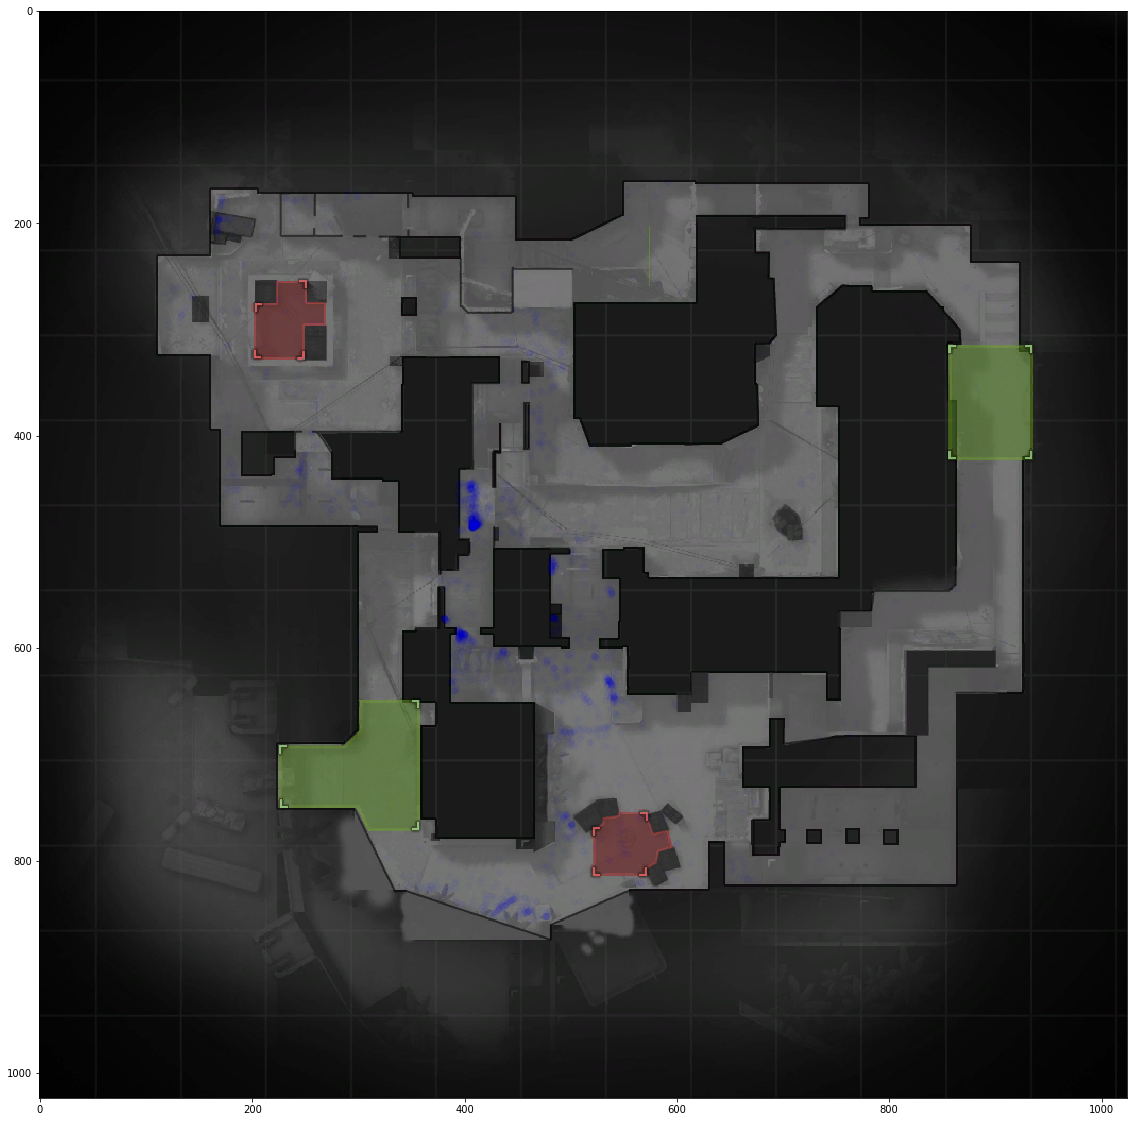

In [5]:
ct_data_awp = data[(data.is_bomb_planted == False) & (data.att_side == 'CounterTerrorist') & (data.wp == 'AWP') & (data.winner_side == 'CounterTerrorist')]

# Code from billfreeman44 | See his kernel : https://www.kaggle.com/billfreeman44/finding-classic-smokes-by-t-side-on-mirage 
im = plt.imread('../input/de_mirage.png')
plt.figure(figsize=(20,20))
t = plt.imshow(im)
t = plt.scatter(ct_data_awp['attacker_mapX'], ct_data_awp['attacker_mapY'],alpha=0.025,c='blue')

### **Strategic Conclusions: AWP Defensive Positioning**

The AWP heatmap reveals a heavy reliance on **Long-Range Corridors** and **Deep Site Anchors**. Unlike the general defensive map, the AWP clusters are concentrated in areas with maximum "Sightline Distance."

#### **1. The "Middle" Monopoly**
* **Window & Connector:** The highest density is found in **Window**. This is the most efficient AWP position on Mirage, as it allows the sniper to contest the entire "Middle" area, neutralizing Terrorist movement before it reaches either site.
* **Top-Mid Suppression:** The presence of blue clusters in **Connector** confirms that successful AWPers prioritize "Mid" control as their primary objective.

#### **2. Bombsite A (Bottom) Efficiency**
* **Stairs & Triple Box:** AWPers favor **Stairs** and **Ticket Booth**. These positions provide a "headshot-only" angle against attackers coming from A-Main or Palace, maximizing the sniper's survival-to-kill ratio.

#### **3. The B-Site Efficiency Gap**
* **Low B-Site Density:** As noted in the visualization, **AWP efficiency on B-Site (Top) is statistically lower.** The clusters at **Van** are smaller and less concentrated. 
* **The Reason:** B-Site is characterized by "Close-Quarter" bottlenecks (Apartments). An AWP at Van is easily overwhelmed by a fast "rush" or utility, making it a high-risk, low-efficiency choice compared to holding the long-range angles of A-Site or Middle.

> **Key Insight:** To maximize the ROI of a $4,750 investment, the data suggests CT teams should prioritize AWP placement in **Window or A-Site**, while utilizing more mobile weaponry (SMGs/Rifles) to hold the close-range bottlenecks of B-Site.

---
# 3. T-Side Defense Analysis (Post-Plant)

**Overview:**
Once the bomb is planted, the Terrorists (T) transition from attackers to defenders. Success is no longer measured by map control, but by **objective retention**. In this dataset, post-plant actions represent only ~16% of total events, making this a "high-stakes" phase where every position is critical.

### **3.1. Bombsite A: Post-Plant Geometry**

In this analysis, we filter for successful Terrorist rounds where the bomb was planted at **Site A**. This reveals how winning teams set up their "crossfires" to deny the Counter-Terrorist (CT) retake.

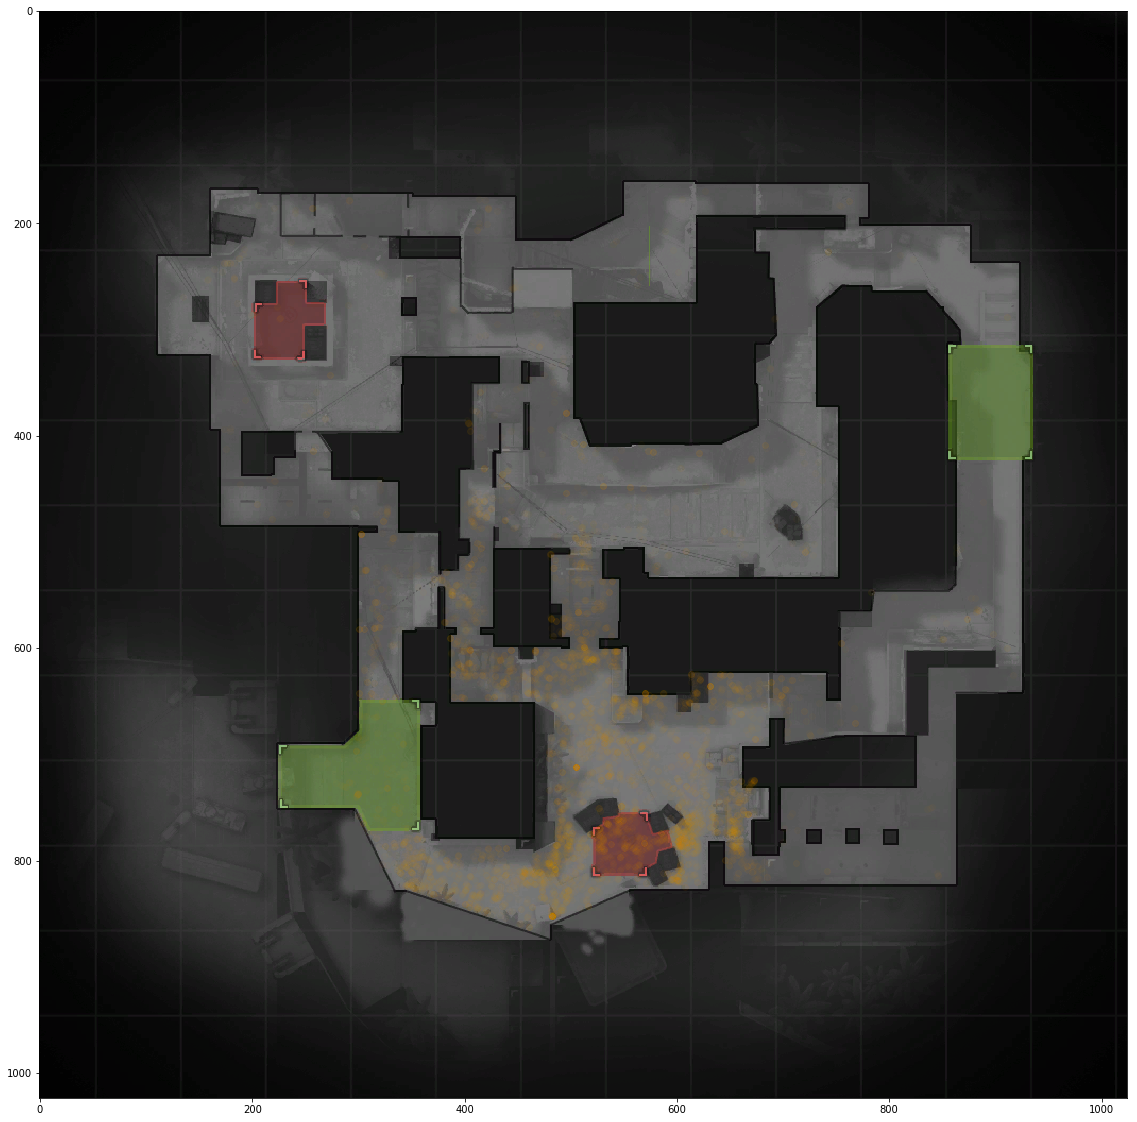

In [6]:
t_data_siteA = data[(data.is_bomb_planted == True) & (data.att_side == 'Terrorist') & (data.bomb_site == 'A') & (data.winner_side == 'Terrorist')]

# Code from billfreeman44 | See his kernel : https://www.kaggle.com/billfreeman44/finding-classic-smokes-by-t-side-on-mirage 
im = plt.imread('../input/de_mirage.png')
plt.figure(figsize=(20,20))
t = plt.imshow(im)
t = plt.scatter(t_data_siteA['attacker_mapX'], t_data_siteA['attacker_mapY'],alpha=0.025,c='orange')

#### **Strategic Analysis & Conclusions**

The orange density clusters show a clear tactical preference for **Peripheral Defense**:

* **The "Lethal Triangle" (Palace, Tetris, & Connector):** The highest density of successful engagements occurs at **Palace/Under-Palace** and **Connector**. By holding these "Deep" positions, Terrorists create a wide crossfire that forces CTs to clear multiple 90-degree angles simultaneously.
* **Proximity vs. Effectiveness:** There is a clear statistical trend: **The further a position is from the bomb, the less effective it becomes for the T-side.** While "hunting" CTs is common, winning rounds are characterized by players staying within a "Support Radius" of the site.
* **The "Firebox/Bitch" Paradox:** Interestingly, the position in the right corner behind the boxes (commonly called "Firebox" or "Bitch") shows high player frequency but lower efficiency in isolation. The data suggests that while people play it often, it is a "death trap" unless supported by a teammate in Palace or Stairs.
* **CT-Spawn Pressure:** Successful T-side defenses often involve one player pushing toward **CT-Spawn** or **Jungle** to intercept rotators early, rather than waiting for the retake to reach the site.

> **Key Takeaway:** A winning Post-Plant defense on A-Site is not about "hiding" on the site; it is about controlling the **access corridors** (Connector and Palace). Positioning further than these zones significantly decreases the probability of a round win.

---
### **3.2. Bombsite B: Post-Plant Geometry**

While the positioning on B-site often appears more "chaotic" due to the smaller, enclosed nature of the site, the winning clusters reveal a highly effective **Defensive Perimeter**.

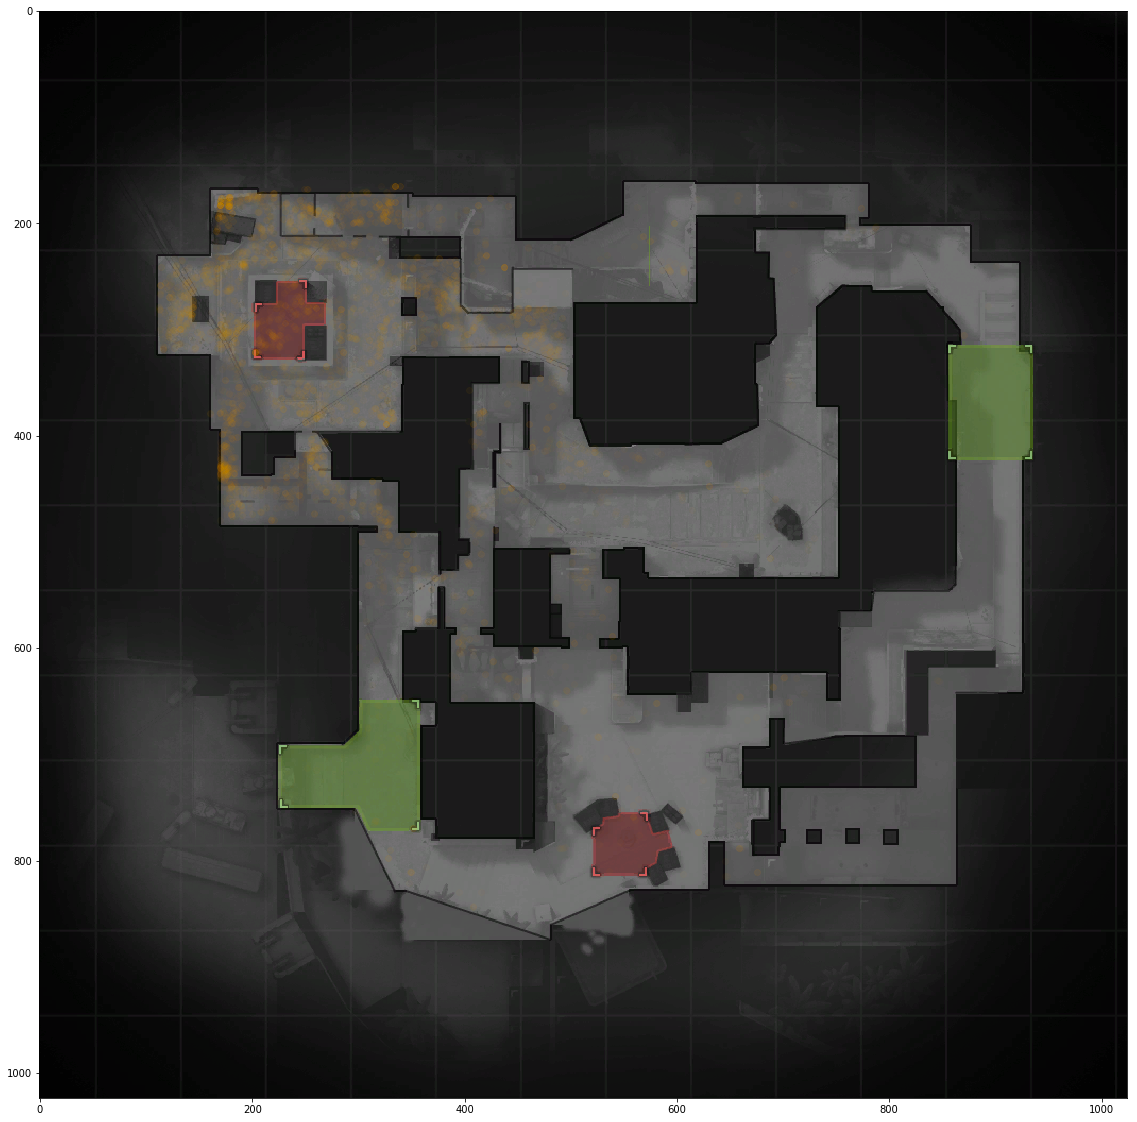

In [7]:
t_data_siteB = data[(data.is_bomb_planted == True) & (data.att_side == 'Terrorist') & (data.bomb_site == 'B') & (data.winner_side == 'Terrorist')]

# Code from billfreeman44 | See his kernel : https://www.kaggle.com/billfreeman44/finding-classic-smokes-by-t-side-on-mirage 
im = plt.imread('../input/de_mirage.png')
plt.figure(figsize=(20,20))
t = plt.imshow(im)
t = plt.scatter(t_data_siteB['attacker_mapX'], t_data_siteB['attacker_mapY'],alpha=0.025,c='orange')

#### **Strategic Analysis & Conclusions**

The orange clusters indicate that successful Terrorist defenses on B-site rely on **Cover-Rich Anchors**:

* **The Market/Kitchen Presence:** Significant density at the **Market (Kitchen) window and door** shows that winning teams prioritize controlling the CT rotation path. By holding this area, Terrorists prevent CTs from ever reaching the site safely.
* **The "Bench" & "Van" Strongholds:** Winning rounds show a high concentration of players at **Bench** and **Van**. These positions provide solid cover and allow players to "play the clock," forcing CTs to check deep corners while the bomb timer expires.
* **Apartments (Appartments) Utility:** The clusters remaining in **Apartments** suggest a "Long-Distance" defense strategy. By keeping one player back in the apartments, the T-side ensures they have a safe "post-plant" view of the bomb that is extremely difficult for CTs to clear without utility.
* **Site Geometry:** Unlike A-site, where "Deep" positions were better, B-site success is found in **Close-Quarter Crossfires**. The proximity of Bench, Van, and Market creates a triangle of fire that covers every possible CT entry point.

> **Key Takeaway:** Efficiency on B-site is achieved through **cover-based positioning**. Holding Market and Bench allows Terrorists to maximize their "Time-to-Kill" while minimizing exposure, which is the statistically superior way to defend the Top Site.

---

# 4. Final Conclusion: The Mirage Strategic Playbook

Through this spatial analysis of over 30,000 rounds, we have quantified the "Winning Geometry" of Mirage. Success in competitive play is not just about individual skill, but about **positional efficiency**.

### **Core Insights:**

* **Offensive vs. Defensive ROI:** * **Terrorists (T):** The most efficient post-plant tactic is **"Peripheral Anchoring."** By playing deep into the site with significant cover (Market, Bench, Palace), winning teams maximize their "Survival-to-Kill" ratio and force CTs into predictable retake paths.
* **Counter-Terrorists (CT):** Success is found in **"Contact Suppression."** Winning teams prioritize semi-aggressive positions near contact points (Van, Connector, Window) to disrupt the T-side execution early rather than playing from the back of the site.

* **Asset Allocation (AWP):** * The AWP is statistically most efficient when holding **Middle and Bombsite A**. Due to the close-quarter nature of B-site apartments, a sniper investment on B yields lower ROI compared to a mobile rifler.

* **Spatial Priorities:** * CT defense is heavily weighted toward **Mid and Bombsite A control**. This trade-off often leads to B-site being treated as a "Retake Scenario," where defenders concede the plant to favor a coordinated five-man push through Market and Short.

---

### **Acknowledgments & Next Steps**
Thank you for exploring this spatial analysis. This project demonstrates how raw telemetry can be transformed into tactical intelligence. 

I highly recommend checking out **billfreeman44’s** kernel on [T-Side Smokes on Mirage](https://www.kaggle.com/billfreeman44/finding-classic-smokes-by-t-side-on-mirage), which perfectly complements this positioning study by showing how utility allows teams to take these high-efficiency positions in the first place.
